In [1]:
import py_wake 

# setup site, wind turbines and wind farm model with the corresponding wake models
import numpy as np
import ipywidgets 
from ipywidgets import interact
from ipywidgets import IntSlider
import matplotlib.pyplot as plt

from py_wake.flow_map import HorizontalGrid
from py_wake.deficit_models.gaussian import BastankhahGaussianDeficit, BlondelSuperGaussianDeficit2020
from py_wake.deflection_models import JimenezWakeDeflection
from py_wake.turbulence_models import CrespoHernandez
from py_wake.utils.plotting import setup_plot
from py_wake.wind_turbines import WindTurbine
from py_wake.wind_turbines.power_ct_functions import PowerCtFunction, PowerCtTabular
from py_wake.site import UniformWeibullSite
from py_wake.rotor_avg_models import CGIRotorAvg
from py_wake.superposition_models import SquaredSum
from py_wake.flow_map import XYGrid
from py_wake.wind_farm_models import PropagateDownwind, All2AllIterative

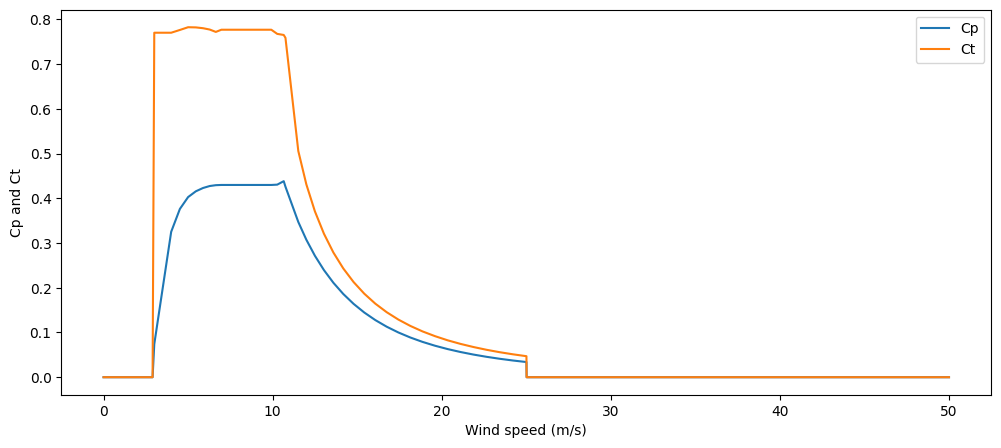

In [2]:
# Define turbine iea_10MW
Cp_u_values = [0.000000,
          0.000000,
          0.074,
          0.325100,
          0.376200,
          0.402700,
          0.415600,
          0.423000,
          0.427400,
          0.429300,
          0.429800,
          0.429800,
          0.429800,
          0.429800,
          0.429800,
          0.429800,
          0.429800,
          0.429800,
          0.429800,
          0.429800,
          0.429800,
          0.429800,
          0.429800,
          0.429800,
          0.429800,
          0.429800,
          0.429800,
          0.429800,
          0.429800,
          0.430500,
          0.438256,
          0.425908,
          0.347037,
          0.307306,
          0.271523,
          0.239552,
          0.211166,
          0.186093,
          0.164033,
          0.144688,
          0.127760,
          0.112969,
          0.100062,
          0.088800,
          0.078975,
          0.070401,
          0.062913,
          0.056368,
          0.050640,
          0.045620,
          0.041216,
          0.037344,
          0.033935,
          0.0,
          0.0]

Cp_u_wind_speeds =[ 
          0.0000,
          2.9,
          3.0,
          4.0000,
          4.5147,
          5.0008,
          5.4574,
          5.8833,
          6.2777,
          6.6397,
          6.9684,
          7.2632,
          7.5234,
          7.7484,
          7.9377,
          8.0909,
          8.2077,
          8.2877,
          8.3308,
          8.3370,
          8.3678,
          8.4356,
          8.5401,
          8.6812,
          8.8585,
          9.0717,
          9.3202,
          9.6035,
          9.9210,
          10.2720,
          10.6557,
          10.7577,
          11.5177,
          11.9941,
          12.4994,
          13.0324,
          13.5920,
          14.1769,
          14.7859,
          15.4175,
          16.0704,
          16.7432,
          17.4342,
          18.1421,
          18.8652,
          19.6019,
          20.3506,
          21.1096,
          21.8773,
          22.6519,
          23.4317,
          24.2150,
          25.010,
          25.020,
          50.0] 
Ct_u_values = [
          0.0,
          0.0,
          0.7701,
          0.7701,
          0.7763,
          0.7824,
          0.7820,
          0.7802,
          0.7772,
          0.7719,
          0.7768,
          0.7768,
          0.7768,
          0.7768,
          0.7768,
          0.7768,
          0.7768,
          0.7768,
          0.7768,
          0.7768,
          0.7768,
          0.7768,
          0.7768,
          0.7768,
          0.7768,
          0.7768,
          0.7768,
          0.7768,
          0.7768,
          0.7675,
          0.7651,
          0.7587,
          0.5056,
          0.4310,
          0.3708,
          0.3209,
          0.2788,
          0.2432,
          0.2128,
          0.1868,
          0.1645,
          0.1454,
          0.1289,
          0.1147,
          0.1024,
          0.0918,
          0.0825,
          0.0745,
          0.0675,
          0.0613,
          0.0559,
          0.0512,
          0.0470,
          0.0,
          0.0]

Ct_u_wind_speeds =[ 
          0.0000,
          2.9,
          3.0,
          4.0000,
          4.5147,
          5.0008,
          5.4574,
          5.8833,
          6.2777,
          6.6397,
          6.9684,
          7.2632,
          7.5234,
          7.7484,
          7.9377,
          8.0909,
          8.2077,
          8.2877,
          8.3308,
          8.3370,
          8.3678,
          8.4356,
          8.5401,
          8.6812,
          8.8585,
          9.0717,
          9.3202,
          9.6035,
          9.9210,
          10.2720,
          10.6557,
          10.7577,
          11.5177,
          11.9941,
          12.4994,
          13.0324,
          13.5920,
          14.1769,
          14.7859,
          15.4175,
          16.0704,
          16.7432,
          17.4342,
          18.1421,
          18.8652,
          19.6019,
          20.3506,
          21.1096,
          21.8773,
          22.6519,
          23.4317,
          24.2150,
          25.010,
          25.020,
          50.0] 

hub_height = 119.0
rotor_diameter = 198.0
TSR = 8.0
ref_density_cp_ct = 1.225
shaft_tilt = 5               # in deg  # TODO Copied from DTU 10MW - Change!

fig = plt.figure(figsize=(12, 5))
ax1 = fig.gca()
ax1.plot(Cp_u_wind_speeds, Cp_u_values, label='Cp')
ax1.plot(Ct_u_wind_speeds, Ct_u_values, label='Ct')
ax1.set_xlabel('Wind speed (m/s)')
ax1.set_ylabel('Cp and Ct')
ax1.legend()

In [16]:
# define turbine and site    
# ws = np.array(Ct_u_wind_speeds)
# ct = np.array(Ct_u_values)
# cp = np.array(Cp_u_values)

# power_curve = 0.5 * 1.225 * (np.pi * (rotor_diameter/2)**2) * ws**3 * cp / 1e6  # Power in MW
# wind_turbine = WindTurbine(name='iea_10mw', diameter=rotor_diameter, hub_height=hub_height, powerCtFunction=PowerCtTabular(ws, power_curve, 'MW', ct))

from py_wake.examples.data.iea22mw.iea_22_rwt import IEA_22MW_280_RWT
wind_turbine = IEA_22MW_280_RWT()
hub_height = wind_turbine.hub_height()
rotor_diameter = wind_turbine.diameter()


In [27]:

# define site (HKN)
wd_site = np.linspace(0,360,12,endpoint=False)
p_wd_site = np.array([0.066,0.063,0.063,0.064,0.054,0.052,0.072,0.129,0.150,0.116,0.091,0.080])
a_site = np.array([9.56,9.21,9.38,9.78,9.23,9.20,10.96,12.73,12.75,12.17,11.22,10.59])
k_site = np.array([2.18,2.36,2.40,2.34,2.30,2.20,2.11,2.33,2.42,2.20,2.15,2.11])
site = UniformWeibullSite(p_wd=p_wd_site,a=a_site,k=k_site,ti=0.06,shear=None)

wf_model = PropagateDownwind(site, 
                             wind_turbine,
                             wake_deficitModel=BlondelSuperGaussianDeficit2020(rotorAvgModel=CGIRotorAvg(9)), 
                             deflectionModel=JimenezWakeDeflection(),
                             turbulenceModel=CrespoHernandez(),
                             superpositionModel=SquaredSum()
                            )

In [28]:
# Run simulation of test wind farm
# Wind farm layout and initial settings
x = np.array([0, 5*rotor_diameter])  # x positions of turbines
y = np.array([0, 0])

print(x)

# Simulate yaw changes over time
time_series = np.arange(0, 2004, 4)  # Simulate for 501 time steps

yaw_table = np.array([[0, 0],       # Same as in OFF example
                      [0, 0],
                      [30, 0],
                      [30, 0],
                      [0, 0],
                      [0, 0],
                      [0, 0]])
# yaw_table = np.array([[0, 0, 0, 0],       # Same as in OFF example
#                       [0, 0, 0, 0],
#                       [30, 0, 0, 0],
#                       [30, 20, 0, 0],
#                       [0, 20, 0, 0],
#                       [0, 0, 0, 0],
#                       [0, 0, 0, 0]])

yaw_table_t = np.array([0.0, 604.0, 700.0, 800.0, 900.0, 1000.0, 90000.0])  # Time points for yaw changes
yaw_table_interp = np.array([np.interp(time_series, yaw_table_t, yaw_table[:, i]) for i in range(yaw_table.shape[1])]).T  # Interpolate yaw angles for each time step

# For PyWake time series mode:
# - time: array of time values
# - ws and wd: must have same length as time array
# - yaw: shape (n_wt, n_time)

ws_array = np.ones(len(time_series)) * 8.0  # Wind speed constant at 8 m/s for all time steps
wd_array = np.ones(len(time_series)) * 270.0  # Wind direction constant at 270 degrees for all time steps

# Yaw array shape: (n_wt, n_time) = (n_t, 501)
yaw_array = yaw_table_interp.T

print(f"Array shapes:")
print(f"  time: {time_series.shape}")
print(f"  ws: {ws_array.shape}")
print(f"  wd: {wd_array.shape}")
print(f"  yaw: {yaw_array.shape}")

# Run PyWake simulation with time series
sim_res = wf_model(x, y,                    # wind turbine positions
                   h=None,                  # wind turbine heights (defaults to the heights defined in windTurbines)
                   type=0,                  # Wind turbine types
                   wd=wd_array,             # Wind direction (time series)
                   ws=ws_array,             # Wind speed (time series)
                   time=time_series,        # Time array
                   yaw=yaw_array,           # Yaw angles shaped as (n_wt, n_time)
                   tilt=5.0                 # Tilt angle (constant)
                  )

print("Simulation complete!")

# Extract power data
# In time series mode, dimensions are: (time, wt)
power_time_series = sim_res.Power.values/1e6  # Shape: (n_time, n_wt) = (501, 2)


[   0. 1420.]
Array shapes:
  time: (501,)
  ws: (501,)
  wd: (501,)
  yaw: (2, 501)
Simulation complete!


In [29]:
# Load OFF simulation results
import os
import pandas as pd

BASE_DIR = os.path.join(os.getcwd(), 'OFF', 'runs')
if not os.path.isdir(BASE_DIR):
    BASE_DIR = os.getcwd()

# Specify the OFF run directory to load
RUN_DIR = os.path.join(BASE_DIR, 'off_run_20260226150850823295')

# Load measurements.csv
measurements_file = os.path.join(RUN_DIR, 'measurements.csv')
if os.path.exists(measurements_file):
    df_OFF = pd.read_csv(measurements_file)
    print(f"Loaded {len(df_OFF)} rows from OFF measurements")
    print(f"Columns: {list(df_OFF.columns)}")
    
    # Extract power time series for each turbine
    # Assuming columns: time, t_idx, power_OFF (or similar)
    turbine_indices = sorted(df_OFF['t_idx'].unique()) if 't_idx' in df_OFF.columns else [0]
    n_turbines = len(turbine_indices)
    
    # Get time points (assuming same for all turbines)
    time_OFF = df_OFF[df_OFF['t_idx'] == turbine_indices[0]]['time'].values if 't_idx' in df_OFF.columns else df_OFF['time'].values
    n_times = len(time_OFF)
    
    # Initialize power array: shape (n_turbines, n_times)
    power_time_series_OFF = np.zeros((n_turbines, n_times))
    
    # Fill power array
    for i, t_idx in enumerate(turbine_indices):
        if 't_idx' in df_OFF.columns:
            df_turb = df_OFF[df_OFF['t_idx'] == t_idx]
        else:
            df_turb = df_OFF
        # Extract power column (check common names)
        power_col = None
        for col_name in ['Power_PyWake', 'power', 'Power', 'P']:
            if col_name in df_turb.columns:
                power_col = col_name
                break
        
        if power_col:
            power_time_series_OFF[i, :] = df_turb[power_col].values/1e6   # Convert to MW
    
    print(f"Power time series shape: {power_time_series_OFF.shape} (turbines x time)")
    print(f"Time range: {time_OFF[0]:.1f} to {time_OFF[-1]:.1f} seconds")
else:
    print(f"Measurements file not found: {measurements_file}")
    power_time_series_OFF = None
    time_OFF = None


Loaded 1002 rows from OFF measurements
Columns: ['Unnamed: 0', 't_idx', 'u_abs_eff_PyWake', 'Ct_PyWake', 'AI_PyWake', 'TI_PyWake', 'Power_PyWake', 'power_OFF', 'time']
Power time series shape: (2, 501) (turbines x time)
Time range: 0.0 to 2000.0 seconds


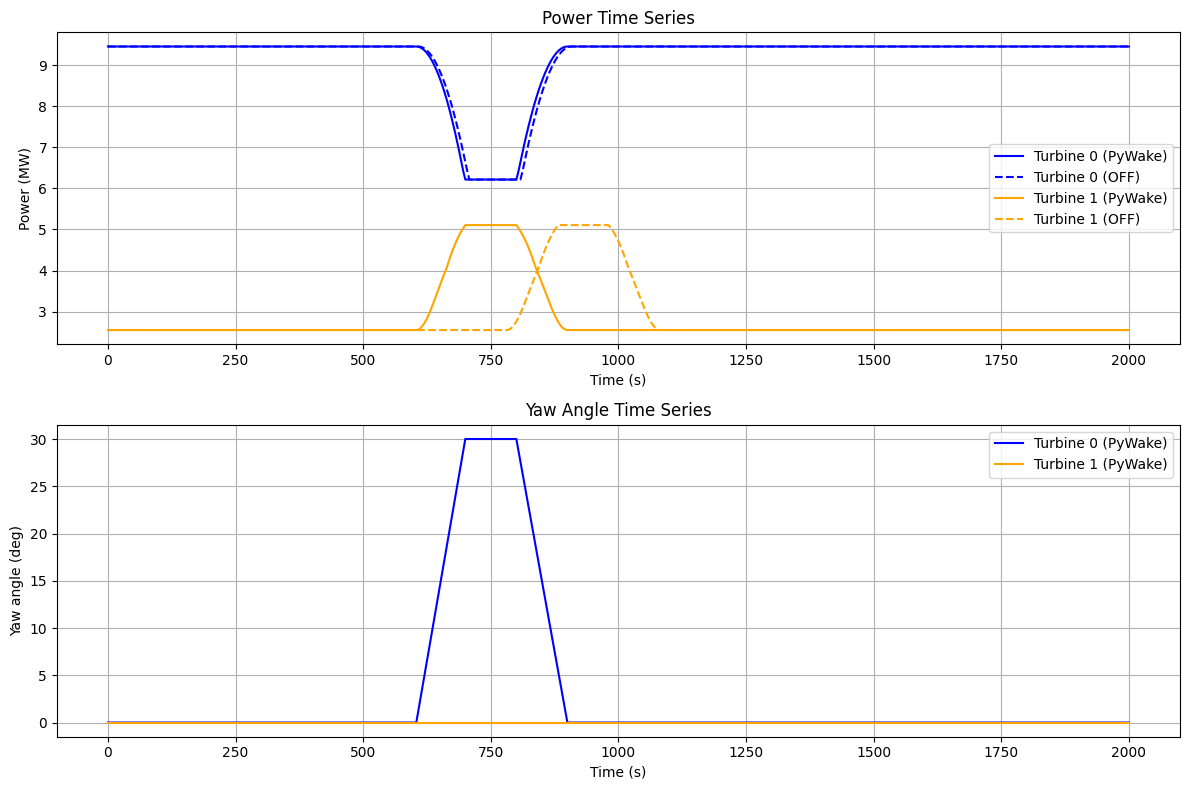

In [30]:
# Plot power over time for each turbine
fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(12, 8))
plot_colors = ['blue', 'orange', 'green', 'red']
# Power time series
for i in range(len(x)):
    ax3.plot(time_series, power_time_series[i, :], label=f'Turbine {i} (PyWake)', color=plot_colors[i])
    ax3.plot(time_OFF, power_time_series_OFF[i, :], label=f'Turbine {i} (OFF)', linestyle='--', color=plot_colors[i])
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Power (MW)')
ax3.set_title('Power Time Series')
ax3.legend()
ax3.grid(True)

# Yaw angles time series
for i in range(len(x)):
    ax4.plot(time_series, yaw_array[i, :], label=f'Turbine {i} (PyWake)', color=plot_colors[i])
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Yaw angle (deg)')
ax4.set_title('Yaw Angle Time Series')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

In [33]:
# Run simulation of test wind farm
# Wind farm layout and initial settings
x = np.array([0, 5*rotor_diameter])  # x positions of turbines
y = np.array([0, 0])

# Simulate yaw changes over time
time_series = np.arange(0, 2004, 4)  # Simulate for 501 time steps

wd_table = np.array([[270],      # Same as in OFF example
                    [260],
                    [265],
                    [275],
                    [285],
                    [270]])

# yaw_table = np.array([[0, 0, 0, 0],       # Same as in OFF example
#                       [0, 0, 0, 0],
#                       [30, 0, 0, 0],
#                       [30, 20, 0, 0],
#                       [0, 20, 0, 0],
#                       [0, 0, 0, 0],
#                       [0, 0, 0, 0]])

wd_table_t = np.array([0.0, 200.0, 250.0, 600.0, 800.0, 1200.0])  # Time points for yaw changes
wd_table_interp = np.array([np.interp(time_series, wd_table_t, wd_table[:, i]) for i in range(wd_table.shape[1])]).T  # Interpolate yaw angles for each time step

# For PyWake time series mode:
# - time: array of time values
# - ws and wd: must have same length as time array
# - yaw: shape (n_wt, n_time)

ws_array = np.ones(len(time_series)) * 8.0  # Wind speed constant at 8 m/s for all time steps
# wd_array = np.ones(len(time_series)) * 270.0  # Wind direction constant at 270 degrees for all time steps

# Yaw array shape: (n_wt, n_time) = (n_t, 501)
wd_array = wd_table_interp.flatten()
yaw_array = np.zeros((2, len(wd_array)))  # No yaw changes, only wind direction changes

print(f"Array shapes:")
print(f"  time: {time_series.shape}")
print(f"  ws: {ws_array.shape}")
print(f"  wd: {wd_array.shape}")
print(f"  yaw: {yaw_array.shape}")

# Run PyWake simulation with time series
sim_res = wf_model(x, y,                    # wind turbine positions
                   h=None,                  # wind turbine heights (defaults to the heights defined in windTurbines)
                   type=0,                  # Wind turbine types
                   wd=wd_array,             # Wind direction (time series)
                   ws=ws_array,             # Wind speed (time series)
                   time=time_series,        # Time array
                   yaw=yaw_array,           # Yaw angles shaped as (n_wt, n_time)
                   tilt=5.0                 # Tilt angle (constant)
                  )

print("Simulation complete!")

# Extract power data
# In time series mode, dimensions are: (time, wt)
power_time_series = sim_res.Power.values/1e6  # Shape: (n_time, n_wt) = (501, 2)


Array shapes:
  time: (501,)
  ws: (501,)
  wd: (501,)
  yaw: (2, 501)
Simulation complete!


In [37]:
# Load OFF simulation results
import os
import pandas as pd

BASE_DIR = os.path.join(os.getcwd(), 'OFF', 'runs')
if not os.path.isdir(BASE_DIR):
    BASE_DIR = os.getcwd()

# Specify the OFF run directory to load
RUN_DIR = os.path.join(BASE_DIR, 'off_run_20260226162925406491')

# Load measurements.csv
measurements_file = os.path.join(RUN_DIR, 'measurements.csv')
if os.path.exists(measurements_file):
    df_OFF = pd.read_csv(measurements_file)
    print(f"Loaded {len(df_OFF)} rows from OFF measurements")
    print(f"Columns: {list(df_OFF.columns)}")
    
    # Extract power time series for each turbine
    # Assuming columns: time, t_idx, power_OFF (or similar)
    turbine_indices = sorted(df_OFF['t_idx'].unique()) if 't_idx' in df_OFF.columns else [0]
    n_turbines = len(turbine_indices)
    
    # Get time points (assuming same for all turbines)
    time_OFF = df_OFF[df_OFF['t_idx'] == turbine_indices[0]]['time'].values if 't_idx' in df_OFF.columns else df_OFF['time'].values
    n_times = len(time_OFF)
    
    # Initialize power array: shape (n_turbines, n_times)
    power_time_series_OFF = np.zeros((n_turbines, n_times))
    
    # Fill power array
    for i, t_idx in enumerate(turbine_indices):
        if 't_idx' in df_OFF.columns:
            df_turb = df_OFF[df_OFF['t_idx'] == t_idx]
        else:
            df_turb = df_OFF
        # Extract power column (check common names)
        power_col = None
        for col_name in ['Power_PyWake', 'power', 'Power', 'P']:
            if col_name in df_turb.columns:
                power_col = col_name
                break
        
        if power_col:
            power_time_series_OFF[i, :] = df_turb[power_col].values/1e6   # Convert to MW
    
    print(f"Power time series shape: {power_time_series_OFF.shape} (turbines x time)")
    print(f"Time range: {time_OFF[0]:.1f} to {time_OFF[-1]:.1f} seconds")
else:
    print(f"Measurements file not found: {measurements_file}")
    power_time_series_OFF = None
    time_OFF = None


Loaded 1002 rows from OFF measurements
Columns: ['Unnamed: 0', 't_idx', 'u_abs_eff_PyWake', 'Ct_PyWake', 'AI_PyWake', 'TI_PyWake', 'Power_PyWake', 'power_OFF', 'time']
Power time series shape: (2, 501) (turbines x time)
Time range: 0.0 to 2000.0 seconds


C:\Users\daanvanderhoek\AppData\Local\Temp\ipykernel_6828\3197713988.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


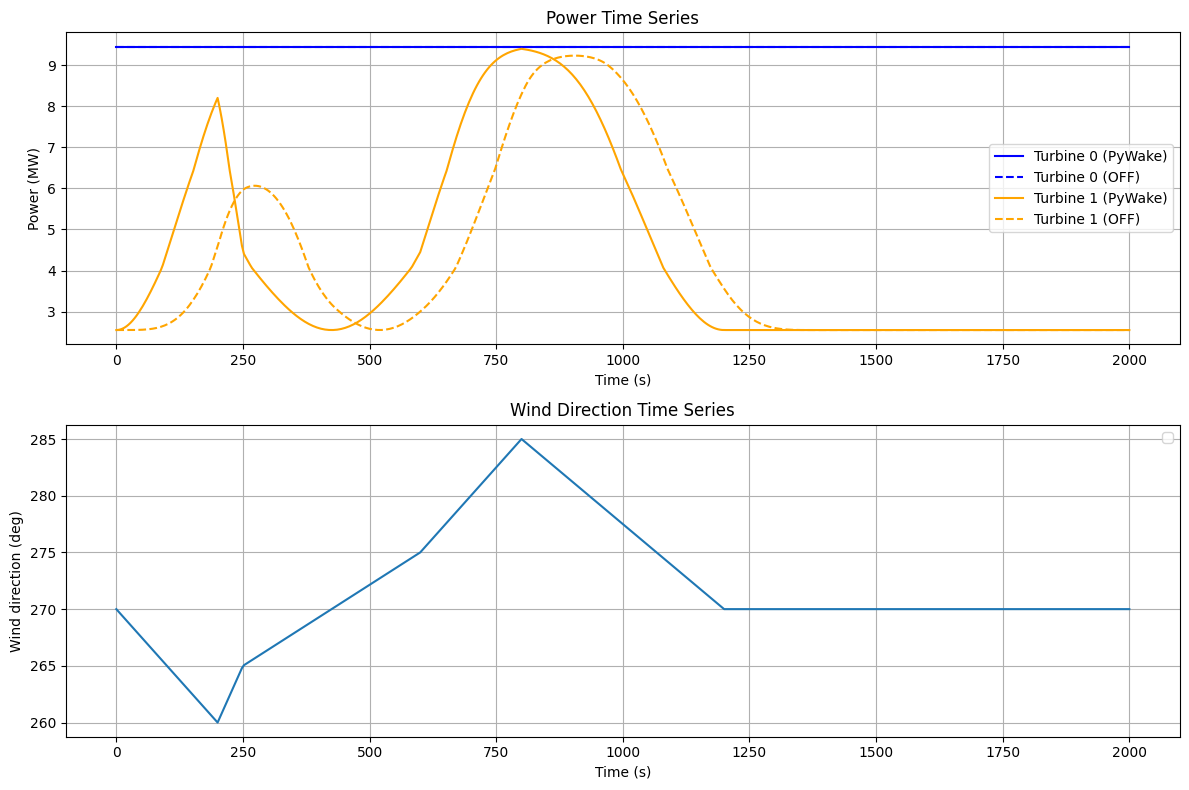

In [38]:
# Plot power over time for each turbine
fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(12, 8))
plot_colors = ['blue', 'orange', 'green', 'red']
# Power time series
for i in range(len(x)):
    ax3.plot(time_series, power_time_series[i, :], label=f'Turbine {i} (PyWake)', color=plot_colors[i])
    ax3.plot(time_OFF, power_time_series_OFF[i, :], label=f'Turbine {i} (OFF)', linestyle='--', color=plot_colors[i])
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Power (MW)')
ax3.set_title('Power Time Series')
ax3.legend()
ax3.grid(True)

# Yaw angles time series
ax4.plot(time_series, wd_array)
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Wind direction (deg)')
ax4.set_title('Wind Direction Time Series')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()